# ARIM-Academy：　基礎編　Scikit-learn（予測モデル）

**対象読者：** Python基礎文法を理解している方。`Scikit-learn-3_EDA.ipynb`（大気腐食データのEDA編）および`Scikit-learn-2_ML.ipynb`（住宅価格予測編）を先に学習していることを前提とします。

**前提知識：** 訓練/テストデータの分割、線形回帰・Lasso回帰・ランダムフォレストの構築方法、過学習の考え方は`Scikit-learn-2_ML.ipynb`で説明済みとして省略します。本編で新しく登場する**k-foldクロスバリデーション**は初出の用語として説明します。

**動作環境：** Python 3.10以降 / pandas 2.x / numpy 1.26以降 / matplotlib 3.8以降 / seaborn 0.12以降 / scikit-learn 1.2以降。Google Colabの標準環境であれば満たされます。

**版・ライセンス：** 本ノートブックのコード部分はMITライセンスで提供します。

---

## 本編の目標

この演習では、鉄の大気腐食量を気象データから予測するための『**大気腐食データセット**』を活用し、予測モデルにかかる機械学習の基礎を習得します。

> **本編と住宅価格編の関係：** 本ノートブックは、`Scikit-learn-2_ML.ipynb`（住宅価格予測編）と**まったく同じコードの構成**（線形重回帰→Lasso回帰→ランダムフォレスト→モデル比較）を、題材だけを実際の研究データ（大気腐食）に差し替えて実践するものです。ただし、データセットの性質（後述）の違いから、住宅価格編ではなかった**新しい注意点**がいくつか出てきます。特に、サンプル数が71件と少ないことに起因する評価の不安定さは、本編で新たに扱う重要な論点です。

### 本編における内容　`（　）内は本ノートブックのコードでの実施範囲`
* **予測アルゴリズムの習得**（実施：線形重回帰・Lasso回帰・ランダムフォレストの3モデル）: このデータセットは、6か所で月次に測定された腐食量データを含んでいます。これを用いて、予測アルゴリズムを学び、腐食量の予測を実践します。

* **特徴選択の理解**（実施：Lasso回帰による係数の縮小。次元削減（PCAなど）は扱いません）: 気象因子を特徴量とするこのデータセットを分析し、適切な特徴量の選択を行うことで、モデルのパフォーマンスを向上させる方法を理解します。

* **モデル評価とパフォーマンス指標の理解**（実施：決定係数R²、train/testの単純分割に加えて**k-foldクロスバリデーション**）: データセットを使用してトレーニングしたモデルを評価し、R²などのパフォーマンス指標を用いて予測精度を評価するスキルを習得します。サンプル数が少ない本データセットでは、1回のtrain/test分割だけでは評価が不安定になることも実際に確認します。

* **回帰係数・特徴量重要度の可視化と解釈**（実施：線形回帰・Lassoの回帰係数、ランダムフォレストのfeature_importances_）: 各特徴量が予測にどの程度貢献しているかを可視化し、モデルの解釈に役立てます。

---

## データセット

**大気腐食データセット**は、日本の6地点における月次の標準試験片の腐食量と、当時の気象庁の観測データを組み合わせたものです。このデータセットは、松波らによる『海塩輸送シミュレーションと気象情報を用いた機械学習に基づく大気腐食量評価モデル開発と高精細腐食環境地図の作成』[1] で使用されたデータの一部に基づいています。ただし、本データセットはPython講義用に作成されたもので、論文で使用されたデータセットとは異なるものです。

[1] 松波 成行, 柳生 進二郎, 篠原 正, 片山 英樹, 須藤 仁, 服部 康男, 平口 博丸　"海塩輸送シミュレーションと気象情報を用いた機械学習に基づく大気腐食量評価モデル開発と高精細腐食環境地図の作成", 土木学会論文集A1（構造・地震工学） Vol.75, p141-160(2019) https://www.jstage.jst.go.jp/article/jscejseee/75/2/75_141/_article/-char/ja/

> **サンプル数についての重要な注意：** このデータセットは**71件しかありません**（6地点×約12か月）。住宅価格編で使ったデータセット（506件）と比べてかなり小さく、しかも説明変数は16個あります。サンプル数に対して説明変数が多いと、モデルが不安定になりやすく、特に「1回だけ」の訓練・テスト分割による評価は、分割の仕方（乱数のシード）によって結果が大きく変わってしまう可能性があります。この点は「2. データセットの指定」以降で実際に確認します。

### 腐食観測量
1. **Corrosion**: 腐食速度 （g/m2/y）

### 気象変数
気象データは気象庁の観測値を基にしており、以下の16変数が含まれます。これらの変数は、説明変数として使用します。

1. **AT** : 平均気温（℃）  
2. **HAT** : 日最高気温の平均（℃）  
3. **LAT** : 日最低気温の平均（℃）  
4. **HT** : 最高気温（℃）  
5. **LT** : 最低気温（℃）  
6. **Rain** : 降水量の合計（mm）  
7. **Mrain** : 日降水量の最大（mm）  
8. **Sun** : 日照時間（時間）  
9. **Msnow** : 最深積雪（cm）  
10. **Snow** : 降雪量合計（cm）  
11. **AW** : 平均風速（m/s）  
12. **MW** : 最大風速（m/s）  
13. **PMW** : 最大瞬間風速（m/s）  
14. **Vap** : 平均蒸気圧（hPa）  
15. **Hum** : 平均湿度（％）  
16. **Lhum** : 最小相対湿度（％）
---

### 教材への接続
Google Colab環境でこのノートブックを実行する場合は、次のセルを実行してください。（<font color="red">ローカル環境などGoogle Colabを使わない場合は不要です</font>）

In [ ]:
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_1_scikit-learn.git
%cd Advanced_Tutorial_1_scikit-learn

# 1. データセットの読み込みと前処理

### ライブラリのインポート
この演習で使用するPythonライブラリをimportします。なお、機械学習に関連するscikit-learnライブラリは、後半で別途importします。

In [1]:
#ライブラリ
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib_fontja
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### サンプルファイルの読み込み

`pandas`ライブラリの`read_csv()`関数は、CSVファイルを読み込んで`pandas`の`DataFrame`形式に変換するための関数です。このセクションでは、[data]フォルダ内に保存されている`corrosin_data.csv`ファイルを`DataFrame`として読み込み、その結果を`df`という変数に格納します。

> 本ノートブックは前編（`Scikit-learn-3_EDA.ipynb`）の続きです。前編で行った探索的データ分析（概要統計・箱ひげ図・ペアプロット・相関係数）はここでは繰り返しません。

In [2]:
#データセットの読み込み
df = pd.read_csv('data/corrosin_data.csv', index_col=0)
df

,Month,AT,HAT,LAT,HT,LT,Rain,Mrain,Sun,Msnow,Snow,AW,MW,PMW,Vap,Hum,Lhum,Corrosion
Place,,,,,,,,,,,,,,,,,,
Naha,1,28.3,26.0,31.1,33.6,23.4,178.0,79.0,206.5,0,0,6.0,14.5,20.9,28.5,74,43,674
Naha,2,25.3,23.5,27.7,30.8,19.9,200.0,118.0,129.7,0,0,7.3,22.0,33.6,23.4,72,40,2606
Naha,3,21.3,19.1,23.8,28.5,13.9,121.0,79.0,120.0,0,0,5.0,12.7,20.6,17.4,66,34,546
Naha,4,17.3,15.0,19.6,23.6,10.3,130.0,52.0,89.4,0,0,5.4,14.5,21.5,12.7,64,37,704
Naha,5,16.8,14.1,19.8,23.5,10.6,66.0,36.5,145.4,0,0,5.0,13.1,20.2,11.8,61,32,620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Choshi,8,14.3,10.8,17.6,21.3,3.5,70.5,13.5,232.2,0,0,5.4,15.6,19.2,11.0,67,22,567
Choshi,9,18.2,15.2,21.6,26.1,12.2,151.0,56.5,257.0,0,0,5.7,21.1,26.8,16.6,78,30,541
Choshi,10,21.1,18.9,24.0,27.3,17.1,177.5,56.0,172.3,0,0,4.5,14.3,19.4,22.3,89,46,830


### 不必要な特徴量の削除
pandasライブラリではデータフレームから特定の行や列を削除する操作で`drop()`メソッドを使います。ここではデータフレームdfから観測月のインデックスである'Month'という名前の列を削除します（理由は前編を参照）。

In [3]:
#　記述子（特徴量）の選定および削除
df = df.drop(['Month'],axis = 1)
df

,AT,HAT,LAT,HT,LT,Rain,Mrain,Sun,Msnow,Snow,AW,MW,PMW,Vap,Hum,Lhum,Corrosion
Place,,,,,,,,,,,,,,,,,
Naha,28.3,26.0,31.1,33.6,23.4,178.0,79.0,206.5,0,0,6.0,14.5,20.9,28.5,74,43,674
Naha,25.3,23.5,27.7,30.8,19.9,200.0,118.0,129.7,0,0,7.3,22.0,33.6,23.4,72,40,2606
Naha,21.3,19.1,23.8,28.5,13.9,121.0,79.0,120.0,0,0,5.0,12.7,20.6,17.4,66,34,546
Naha,17.3,15.0,19.6,23.6,10.3,130.0,52.0,89.4,0,0,5.4,14.5,21.5,12.7,64,37,704
Naha,16.8,14.1,19.8,23.5,10.6,66.0,36.5,145.4,0,0,5.0,13.1,20.2,11.8,61,32,620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Choshi,14.3,10.8,17.6,21.3,3.5,70.5,13.5,232.2,0,0,5.4,15.6,19.2,11.0,67,22,567
Choshi,18.2,15.2,21.6,26.1,12.2,151.0,56.5,257.0,0,0,5.7,21.1,26.8,16.6,78,30,541
Choshi,21.1,18.9,24.0,27.3,17.1,177.5,56.0,172.3,0,0,4.5,14.3,19.4,22.3,89,46,830


# 2. 機械学習モデルの構築と比較

このあと、次の3つの回帰モデルを同じ訓練データ・テストデータで構築し、決定係数（R²）と特徴量重要度を比較します。

1. 線形重回帰（Linear Regression）
2. Lasso回帰（L1正則化付き線形回帰）
3. ランダムフォレスト（Random Forest）

さらに、サンプル数が少ないことに起因する評価の不安定さを実際に確認し、その対策として**k-foldクロスバリデーション**を導入します（`Scikit-learn-2_ML.ipynb`の「Closing」で予告していた内容です）。可視化した図には図1〜図9の通し番号を付けています。

### データセットの指定
16の気象データを説明変数、腐食量を目的変数とします。住宅価格編と同様に、`drop()`を使って目的変数の列を明示的に取り除く書き方にします（列の位置に依存する`iloc`は、列の並び順が変わると誤動作するため避けます）。

In [4]:
#腐食量（Corrosion）を目的変数として、それ以外を説明変数とする
X = df.drop('Corrosion', axis=1)  # 説明変数（16列）
y = df['Corrosion']                # 目的変数

### 【解説】説明変数と目的変数

Pythonの操作の観点から説明変数（特徴量）と目的変数（ターゲット変数）について説明します。

機械学習や統計分析では、データセット内の変数を説明変数と目的変数に分けて扱います。

**説明変数**（または特徴量）は、データセット内の独立変数であり、予測や解析のための情報を提供します。これらの変数は、目的変数に影響を与える可能性がある特徴や属性を表しています。説明変数は、予測モデルの入力として使用され、それぞれのデータポイントに関する情報を提供します。

**目的変数**（またはターゲット変数）は、予測や分析の対象となる変数であり、説明変数に基づいて予測される値です。目的変数は、モデルが学習しようとする対象であり、予測の精度やモデルの評価に使用されます。

In [5]:
X

,AT,HAT,LAT,HT,LT,Rain,Mrain,Sun,Msnow,Snow,AW,MW,PMW,Vap,Hum,Lhum
Place,,,,,,,,,,,,,,,,
Naha,28.3,26.0,31.1,33.6,23.4,178.0,79.0,206.5,0,0,6.0,14.5,20.9,28.5,74,43
Naha,25.3,23.5,27.7,30.8,19.9,200.0,118.0,129.7,0,0,7.3,22.0,33.6,23.4,72,40
Naha,21.3,19.1,23.8,28.5,13.9,121.0,79.0,120.0,0,0,5.0,12.7,20.6,17.4,66,34
Naha,17.3,15.0,19.6,23.6,10.3,130.0,52.0,89.4,0,0,5.4,14.5,21.5,12.7,64,37
Naha,16.8,14.1,19.8,23.5,10.6,66.0,36.5,145.4,0,0,5.0,13.1,20.2,11.8,61,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Choshi,14.3,10.8,17.6,21.3,3.5,70.5,13.5,232.2,0,0,5.4,15.6,19.2,11.0,67,22
Choshi,18.2,15.2,21.6,26.1,12.2,151.0,56.5,257.0,0,0,5.7,21.1,26.8,16.6,78,30
Choshi,21.1,18.9,24.0,27.3,17.1,177.5,56.0,172.3,0,0,4.5,14.3,19.4,22.3,89,46


### データセットの分割（Data set splitting）
機械学習モデルの性能を正確に評価するためには、モデルを学習させる**訓練データ**と、学習済みのモデルの性能を評価するための**テストデータ**にデータを分割する必要があります。scikit-learnの`train_test_split()`関数を使用すると、この分割を簡単に実行できます。

> **標準化のタイミングに関する重要な注意：** 標準化（`StandardScaler`）は、訓練データとテストデータに分割した**あと**、訓練データだけを使って基準（平均・標準偏差）を計算し、その基準をテストデータにも適用しなければなりません。分割する**前**にデータ全体で標準化してしまうと、本来モデルが見てはいけないはずのテストデータの情報（全体の平均・標準偏差の計算に使われてしまう）が、訓練時に間接的に漏れてしまいます。これを**データリーケージ（data leakage）**と呼びます。以下のコードでは、先に分割してから、訓練データだけで`fit`した`StandardScaler`を両方に適用する、正しい順序で実装します。

In [6]:
#データセットの分割
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.2,   # ホールドアウト法によるデータ分割
                                                    random_state = 42
                                                    )  

#### 【解説】データセットの分割

`train_test_split`関数は、PythonのScikit-learnライブラリで提供される便利なツールで、データセットをトレーニングデータとテストデータに分割するために使用されます。機械学習モデルを構築する際、データセットを適切に分割してモデルの学習と評価を行うことが重要です。

**トレーニングデータ**を使ってモデルを学習し、**テストデータ**を使ってそのモデルのパフォーマンスを評価します。これにより、モデルが未知のデータに対してどの程度適切に予測できるかを確認できます。

- **`test_size`**: テストデータの割合を指定します。住宅価格編では`test_size=0.2`（20%）を使いました。本編でも同じ0.2を使います。71件の20%は約14件です。決して多くはありませんが、住宅価格編で使った`test_size=0.1`（約7件）よりは安定した評価が期待できます。
- **`random_state`**: 乱数シードを指定することで、データの分割を再現可能にします。

> **なぜ`test_size=0.1`ではなく`0.2`にしたのか：** サンプル数が71件しかない場合、テストデータを7件程度まで減らすと、後述の通り評価が非常に不安定になります。14件でも十分とは言えませんが、住宅価格編との対比のため、まずは標準的な0.2から始めます。

### 標準化
モデルはデータのスケールに敏感であるため、標準化を行います。標準化とは、各特徴量を平均0、標準偏差1にスケーリングする手法で、異なるスケールを持つ特徴量を均等に扱えるようにします。

標準化は、scikit-learnの`StandardScaler`クラスで簡単に行うことができます。**訓練データで`fit`し、その基準を訓練データ・テストデータの両方に`transform`で適用します。**

In [7]:
from sklearn.preprocessing import StandardScaler

# 標準化（訓練データだけでfitし、train/test両方にtransformを適用）
scaler = StandardScaler()
scaler.fit(X_train)

X_train = pd.DataFrame(scaler.transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

In [8]:
X_train

,AT,HAT,LAT,HT,LT,Rain,Mrain,Sun,Msnow,Snow,AW,MW,PMW,Vap,Hum,Lhum
Place,,,,,,,,,,,,,,,,
Fukuoka,0.404553,0.221689,0.661597,0.688740,0.001250,-0.672198,-0.009580,2.315152,-0.144986,-0.144743,-0.579924,-0.314572,-0.402125,-0.256234,-1.330016,-1.475589
Choshi,0.885696,0.942454,0.794126,1.129627,0.922662,-0.161800,-0.546059,0.632609,-0.144986,-0.144743,1.293676,1.625347,2.047709,1.042607,1.192901,1.253574
Shizuoka,1.490562,1.340118,1.618756,1.635830,1.295893,-0.715946,-0.903711,1.188651,-0.144986,-0.144743,-1.142004,-1.117973,-1.326897,1.512664,0.315365,0.343853
Tsukuba,1.133142,0.979735,1.368422,1.570514,0.934326,0.061803,-0.546059,0.134230,-0.144986,-0.144743,-0.767284,-0.628094,-0.531918,1.302376,1.192901,0.192233
Shizuoka,-0.970142,-1.045864,-0.884583,-0.421642,-1.270067,1.996456,2.285357,0.723223,-0.144986,-0.144743,-0.829737,-0.667285,-0.158764,-1.047909,-1.220324,-1.475589
Miyakojima,0.157108,0.321105,-0.045228,-0.356325,0.444461,-0.341654,-0.307624,-1.301183,-0.144986,-0.144743,0.669143,-0.275382,-0.385901,-0.008836,0.315365,0.722903
Fukuoka,0.913190,0.867892,1.015009,0.688740,0.829355,-0.545814,0.169246,-0.180861,-0.144986,-0.144743,-0.704831,-0.255787,-0.759055,0.758099,0.425057,0.192233
Shizuoka,0.198349,0.022857,0.337635,0.296841,0.059567,0.115274,-0.411939,1.691149,-0.144986,-0.144743,-1.017097,-0.784856,-0.402125,-0.169645,-0.342788,-1.020729
Fukuoka,-0.832673,-0.822179,-0.766779,-0.552275,-0.931827,-0.589562,-1.082537,0.140408,-0.144986,-0.144743,-0.267657,0.175307,-0.174988,-0.862360,-0.562172,-0.869108


### モデル選択
scikit-learnは、機械学習モデルの実装や評価を支援するための豊富なツールセットを提供しています。予測タスク（回帰）において、scikit-learnではさまざまな**回帰アルゴリズム**が利用可能です。モデルの選択は、データの特性やタスクの要件に基づいて行う必要があります。

本ノートブックでは、次の3つのモデルを実際に構築し、比較します（住宅価格編と同じ3モデルです）。

1. **線形重回帰（Linear Regression）** — 全ての説明変数を使い、正則化なしで係数を最小二乗法により求めるもっとも基本的なモデルです。
2. **Lasso回帰（L1正則化付き線形回帰）** — 線形回帰にL1正則化を加え、影響の小さい特徴量の係数を0に近づけることで、特徴選択と過学習防止を狙うモデルです。
3. **ランダムフォレスト（Random Forest）** — 複数の決定木を組み合わせたアンサンブル学習モデルで、非線形な関係も捉えられます。

サポートベクター回帰（SVR）やニューラルネットワークなど、他の回帰アルゴリズムも存在しますが、本ノートブックでは扱いません。

## 1. 線形重回帰
機械学習で最も汎用的なモデルの一つである線形重回帰モデルを作成してみましょう。 単回帰分析と同様に、複数の説明変数を用いて目的変数を予測するモデルです。

### ①　モデル構築
LinearRegression クラスは、Scikit-learnライブラリから提供される線形回帰モデルのクラスです。線形重回帰では、複数の特徴量（独立変数）を使用して目的変数（従属変数）を予測するモデルを構築します。

上で標準化を済ませているため、ここでは既に標準化された`X_train`・`X_test`をそのまま使います。

In [9]:
# 線形回帰モデル
from sklearn.linear_model import LinearRegression

#予測器の作成
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### ②　特徴量の評価（重要度）
線形回帰モデルの係数（重み）と切片を出力しましょう。すでに標準化された特徴量を使っているため、係数の絶対値の大きさをそのまま「影響の大きさ」の目安として比較できます（住宅価格編の線形回帰では未標準化だったため、この比較ができませんでした）。

In [20]:
#係数（重み）と切片
print('係数：',model.coef_)
print('切片：',model.intercept_)

係数： [  -0.            0.            0.         -194.86445076  504.28789105
 -123.92062621   10.06265809  -90.89551409   -1.66192756   -1.62997103
  200.54962648 -460.66259832  618.09758762   29.54026795  -49.05626347
  -98.07380689]
切片： 676.2857142857141


In [11]:
#係数をPandasのSeries型に変換
coef = pd.Series(model.coef_, index = X.columns)
coef

AT      -4610.251929
HAT      2915.135029
LAT      1975.347574
HT       -288.662740
LT        342.290051
Rain      -70.209756
Mrain      -6.393758
Sun       -42.810836
Msnow     799.290035
Snow     -790.026831
AW        231.990704
MW       -574.055058
PMW       702.357424
Vap        59.787193
Hum       -81.938496
Lhum     -110.201934
dtype: float64

### 可視化（図1）
線形回帰モデルの各説明変数の係数を棒グラフで可視化し、どの説明変数が目的変数に最も大きな影響を与えているかを視覚的に確認してみましょう。

* **直感的な理解**: 標準化済みの係数なので、棒グラフの長さによって、各説明変数の影響の大きさを比較できます。
* **重要変数の特定**: 絶対値が大きい係数を持つ変数が、目的変数に大きな影響を与えていることがわかります。
* **正負の判断**: 係数の符号から、説明変数と目的変数の関係が正の相関か負の相関かがわかります。

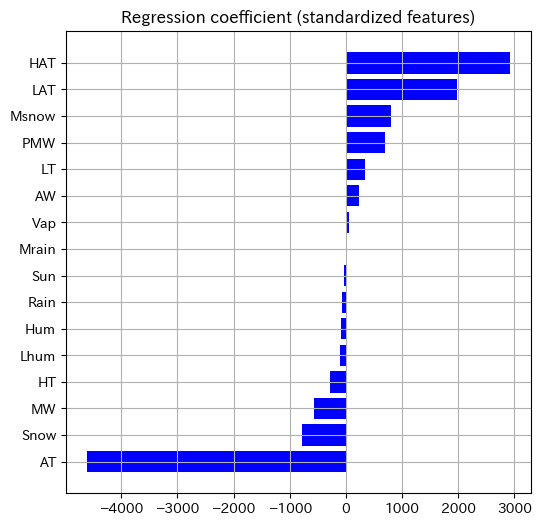

In [12]:
# 回帰係数の可視化
fig, ax = plt.subplots(figsize=(6,6))

imp_coef = coef.sort_values()

ax.barh(imp_coef.index,
        imp_coef,
        color ='blue')

ax.grid()
plt.title('Regression coefficient (standardized features)') 

plt.show() 

### ③　モデルの評価：精度の計算
モデルの汎化性能を評価するために、決定係数（R²スコア）を用いて訓練データとテストデータのスコアを比較します。

**過学習**: モデルが訓練データに過度に適合し、新しいデータに対しては性能が低下する現象です。訓練データのR²スコアが高く、テストデータのR²スコアが低い場合、過学習が疑われます。  
**汎化性能**: モデルが未知のデータに対しても高い予測精度を示す能力です。訓練データとテストデータのR²スコアが近い場合、モデルは汎化性能が高いと考えられます。  

### 訓練データ

In [31]:
#予測値
y_pred_train = model.predict(X_train)

In [14]:
# 訓練データの精度
r2_train_lr = model.score(X_train, y_train)
print('訓練データ決定係数:{:.3f}'.format(r2_train_lr))

訓練データ決定係数:0.830


### テストデータ

In [33]:
#テストデータの予測値
y_pred_test = model.predict(X_test)

In [16]:
# テストデータの精度
r2_test_lr = model.score(X_test, y_test)
print('テストデータ決定係数:{:.3f}'.format(r2_test_lr))

テストデータ決定係数:0.750


### ④　観測値-予測値プロット（図2）
機械学習モデルの予測結果と実際の観測値を散布図で可視化したグラフです。このプロットは、モデルの予測精度を評価し、予測誤差の傾向を把握する上で非常に有効です。

**理想的なプロット**: 予測値と観測値がほぼ一致する場合、データ点が対角線上に近接して分布します。これは、モデルがデータの傾向を正しく捉えていることを示します。  
**誤差の傾向**: データ点が対角線から大きく外れている場合、モデルの予測に誤差が含まれていることを示します。

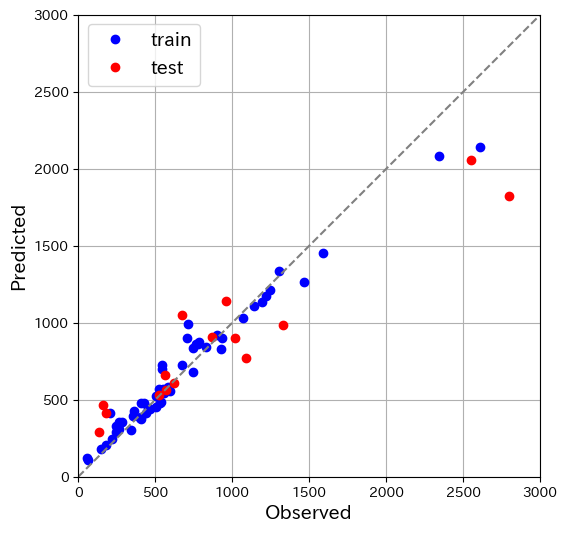

In [35]:
fig, ax = plt.subplots(figsize=(6,6))

#データのプロット
ax.plot(y_train, y_pred_train, 'o', c = 'blue', label ='train')
ax.plot(y_test, y_pred_test, 'o', c = 'red', label ='test')

# 対角線のプロット
ax.plot([0, 3000], [0, 3000], 
        linestyle='--', 
        color ='gray')  

#グラフの修飾
ax.axis('square')
ax.set_xlabel('Observed',fontsize = 14)
ax.set_ylabel('Predicted',fontsize = 14)

ax.set_xlim(0,3000)
ax.set_ylim(0,3000)
ax.legend(fontsize = 14)
ax.grid()

plt.show()

> ### 【重要】この結果を鵜呑みにしてはいけない理由
> テストデータは71件の20%、つまり**わずか約14件**です。この程度の件数では、`random_state`（乱数シード）を変えるだけで決定係数が大きく変動する可能性があります。実際に確認してみましょう。

In [18]:
# random_stateを変えるだけでテストデータの決定係数がどれだけ変動するか確認する
from sklearn.linear_model import LinearRegression as LR_check

for seed in [0, 1, 2, 3, 4, 42, 100]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed)
    sc = StandardScaler().fit(Xtr)
    Xtr_s = sc.transform(Xtr); Xte_s = sc.transform(Xte)
    m = LR_check().fit(Xtr_s, ytr)
    print(f'random_state={seed:3d}  test件数={len(Xte):2d}  訓練R2={m.score(Xtr_s,ytr):.3f}  テストR2={m.score(Xte_s,yte):.3f}')

random_state=  0  test件数=15  訓練R2=0.844  テストR2=0.427
random_state=  1  test件数=15  訓練R2=0.858  テストR2=-3.498
random_state=  2  test件数=15  訓練R2=0.817  テストR2=0.779
random_state=  3  test件数=15  訓練R2=0.852  テストR2=0.363
random_state=  4  test件数=15  訓練R2=0.845  テストR2=0.353
random_state= 42  test件数=15  訓練R2=0.830  テストR2=0.750
random_state=100  test件数=15  訓練R2=0.835  テストR2=0.369


`random_state`を変えただけで、テストデータの決定係数が大きくばらつくことが分かったはずです。71件というサンプル数では、1回だけの訓練・テスト分割による評価は「たまたま良い（悪い）分割を引いた」だけの可能性があり、信頼できません。この問題への対策が、次の「4. k-foldクロスバリデーション」です（線形回帰以外のLasso回帰・ランダムフォレストの評価を先に一通り終えてから、まとめて扱います）。

## 2.Lasso回帰

Lasso回帰は、線形回帰モデルにL1正則化項を追加することで、特徴選択と過学習防止という二つの効果を実現する手法です。

**【1】特徴選択**  
L1正則化項は、モデルの複雑さを抑える働きがあり、多くの場合、一部の回帰係数を厳密に0にします。これにより、目的変数にほとんど影響を与えない無関係な特徴量を自動的にモデルから除外することができます。この特徴選択機能は、高次元のデータにおいて、モデルの解釈性を高め、過学習を防ぐ上で非常に有効です。

**【2】過学習防止**  
L1正則化は、モデルの複雑さを制限することで、過学習を抑制します。過学習とは、モデルが訓練データに過度に適合しすぎてしまい、新しいデータに対しては予測精度が低下する現象です。Lasso回帰は、この過学習問題に対処し、モデルの汎化性能を向上させることができます。  

Lasso回帰は、特徴量が多く、モデルの解釈性や汎化性能を重視する場面で特に有効な手法です。本データセットのように**サンプル数（71件）に対して説明変数（16個）が相対的に多い**場合、特徴選択によってモデルを単純化できるLasso回帰は特に相性の良い手法です。

### ①　モデル構築
Lassoは、Scikit-learnライブラリから提供されるLasso回帰のクラスよりインスタンスを作成することができます。すでに標準化された`X_train`・`X_test`を使うため、線形回帰と同じデータをそのまま使えます。

In [19]:
# Lasso回帰モデル
from sklearn.linear_model import Lasso

#予測器の作成
model = Lasso(random_state=42)
model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


### ②　特徴量の評価（重要度）

In [20]:
#係数（重み）と切片
print('係数：',model.coef_)
print('切片：',model.intercept_)

係数： [  -0.            0.            0.         -194.86445076  504.28789105
 -123.92062621   10.06265809  -90.89551409   -1.66192756   -1.62997103
  200.54962648 -460.66259832  618.09758762   29.54026795  -49.05626347
  -98.07380689]
切片： 676.2857142857141


In [21]:
coef = pd.Series(model.coef_, index = X.columns)
coef

AT        -0.000000
HAT        0.000000
LAT        0.000000
HT      -194.864451
LT       504.287891
Rain    -123.920626
Mrain     10.062658
Sun      -90.895514
Msnow     -1.661928
Snow      -1.629971
AW       200.549626
MW      -460.662598
PMW      618.097588
Vap       29.540268
Hum      -49.056263
Lhum     -98.073807
dtype: float64

### 可視化（図3）

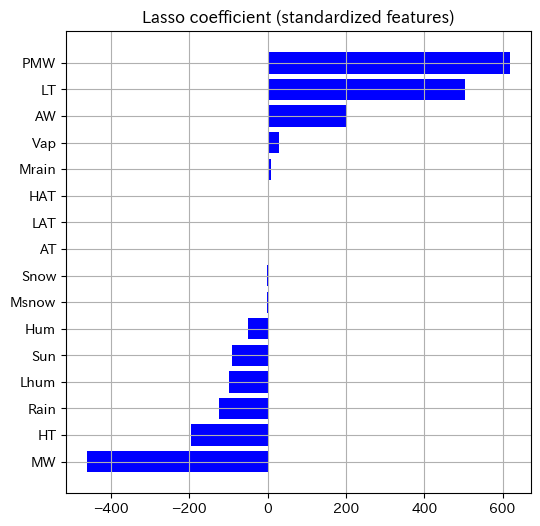

In [22]:
# 回帰係数の可視化
fig, ax = plt.subplots(figsize=(6,6))

imp_coef = coef.sort_values()

ax.barh(imp_coef.index,
        imp_coef,
        color ='blue')

ax.grid()
plt.title('Lasso coefficient (standardized features)') 

plt.show() 

### ③　モデルの評価：精度の計算
### 訓練データ

In [31]:
#予測値
y_pred_train = model.predict(X_train)

In [24]:
# 訓練データの精度
r2_train_lasso = model.score(X_train, y_train)
print('訓練データ決定係数:{:.3f}'.format(r2_train_lasso))

訓練データ決定係数:0.811


### テストデータ

In [33]:
#テストデータの予測値
y_pred_test = model.predict(X_test)

In [26]:
# テストデータの精度
r2_test_lasso = model.score(X_test, y_test)
print('テストデータ決定係数:{:.3f}'.format(r2_test_lasso))

テストデータ決定係数:0.725


### ④　観測値-予測値プロット（図4）

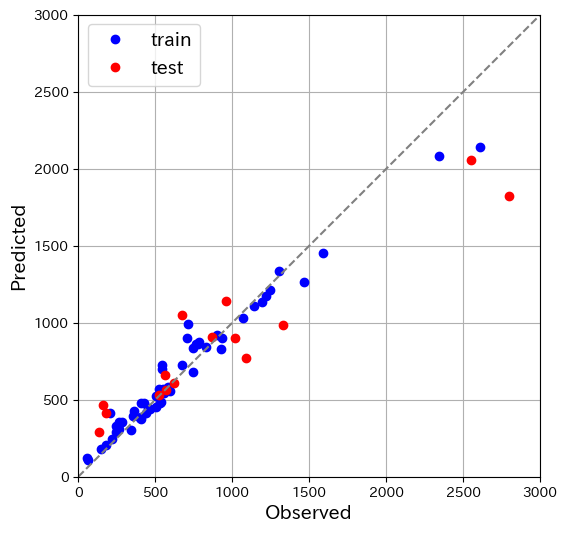

In [35]:
fig, ax = plt.subplots(figsize=(6,6))

#データのプロット
ax.plot(y_train, y_pred_train, 'o', c = 'blue', label ='train')
ax.plot(y_test, y_pred_test, 'o', c = 'red', label ='test')

# 対角線のプロット
ax.plot([0, 3000], [0, 3000], 
        linestyle='--', 
        color ='gray')  

#グラフの修飾
ax.axis('square')
ax.set_xlabel('Observed',fontsize = 14)
ax.set_ylabel('Predicted',fontsize = 14)

ax.set_xlim(0,3000)
ax.set_ylim(0,3000)
ax.legend(fontsize = 14)
ax.grid()

plt.show()

## 3. ランダムフォレスト

ランダムフォレストは、複数の決定木をランダムに組み合わせることで、高い予測精度と安定性を両立させたアンサンブル学習モデルです。主な特徴は以下の通りです。

**【1】アンサンブル学習による高精度化と過学習防止**  
複数の決定木を組み合わせることで、単一の決定木よりもより複雑なパターンを学習し、予測精度を高めることができます。

**【2】特徴量の重要度評価**  
ランダムフォレストは、各特徴量が予測にどれだけ貢献しているかを定量的に評価する機能を持っています。

### ①　モデル構築
`RandomForestRegressor()` は、Scikit-learnにおけるランダムフォレスト回帰のクラスです。住宅価格編と条件を揃えるため、木の本数`n_estimators`はデフォルト値の100を明示的に指定します（木の本数が少ないと予測が不安定になりやすいため、10本のような少ない本数は避けます）。

In [28]:
#ランダムフォレスト回帰
from sklearn.ensemble import RandomForestRegressor

#予測器の作成（n_estimators=100: 住宅価格編と条件を揃える）
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### ②　特徴量の評価（重要度）

In [29]:
coef = pd.Series(model.feature_importances_, index = X.columns)
coef

AT       0.036700
HAT      0.043724
LAT      0.018195
HT       0.016742
LT       0.038281
Rain     0.028592
Mrain    0.017417
Sun      0.031676
Msnow    0.000243
Snow     0.000057
AW       0.215871
MW       0.128562
PMW      0.182370
Vap      0.027541
Hum      0.023102
Lhum     0.190926
dtype: float64

### 可視化（図5）

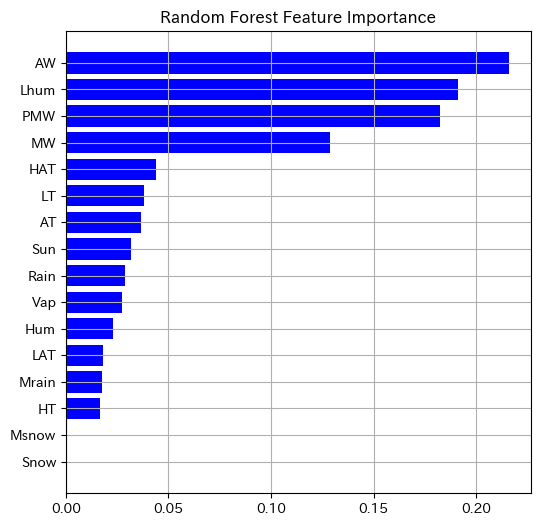

In [30]:
# 特徴量重要度の可視化
fig, ax = plt.subplots(figsize=(6,6))

imp_coef = coef.sort_values()

ax.barh(imp_coef.index,
        imp_coef,
        color ='blue')

ax.grid()
plt.title('Random Forest Feature Importance') 
plt.show()

### ③　モデルの評価：精度の計算
### 訓練データ

In [31]:
#予測値
y_pred_train = model.predict(X_train)

In [32]:
# 訓練データの精度
r2_train_rf = model.score(X_train, y_train)
print('訓練データ決定係数:{:.3f}'.format(r2_train_rf))

訓練データ決定係数:0.950


### テストデータ

In [33]:
#テストデータの予測値
y_pred_test = model.predict(X_test)

In [34]:
# テストデータの精度
r2_test_rf = model.score(X_test, y_test)
print('テストデータ決定係数:{:.3f}'.format(r2_test_rf))

テストデータ決定係数:0.795


### ④　観測値-予測値プロット（図6）

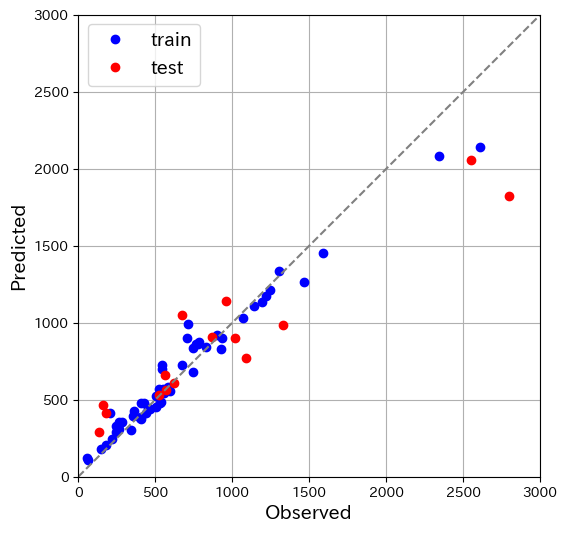

In [35]:
fig, ax = plt.subplots(figsize=(6,6))

#データのプロット
ax.plot(y_train, y_pred_train, 'o', c = 'blue', label ='train')
ax.plot(y_test, y_pred_test, 'o', c = 'red', label ='test')

# 対角線のプロット
ax.plot([0, 3000], [0, 3000], 
        linestyle='--', 
        color ='gray')  

#グラフの修飾
ax.axis('square')
ax.set_xlabel('Observed',fontsize = 14)
ax.set_ylabel('Predicted',fontsize = 14)

ax.set_xlim(0,3000)
ax.set_ylim(0,3000)
ax.legend(fontsize = 14)
ax.grid()

plt.show()

## 4. 3モデルの比較

In [36]:
# 3モデルの決定係数を一覧表にまとめる
comparison = pd.DataFrame({
    '訓練データR²': [r2_train_lr, r2_train_lasso, r2_train_rf],
    'テストデータR²': [r2_test_lr, r2_test_lasso, r2_test_rf],
}, index=['線形重回帰', 'Lasso回帰', 'ランダムフォレスト'])

comparison['差（訓練－テスト）'] = comparison['訓練データR²'] - comparison['テストデータR²']
comparison

,訓練データR²,テストデータR²,差（訓練－テスト）
線形重回帰,0.830359,0.750261,0.080097
Lasso回帰,0.811361,0.725355,0.086006
ランダムフォレスト,0.949520,0.794869,0.154651


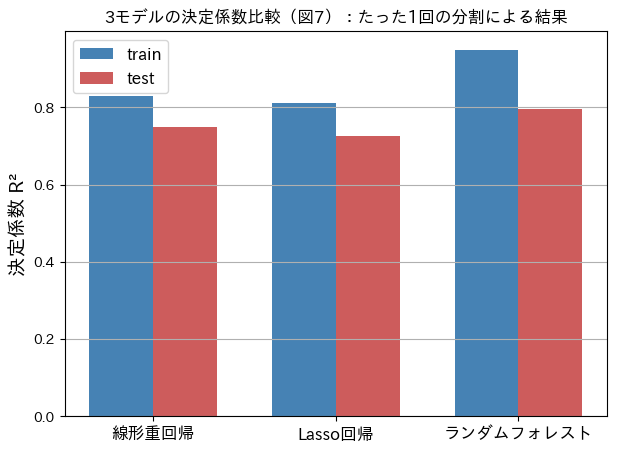

In [37]:
# 図7：3モデルの決定係数を棒グラフで比較
fig, ax = plt.subplots(figsize=(7,5))

x = np.arange(len(comparison.index))
width = 0.35

ax.bar(x - width/2, comparison['訓練データR²'], width, label='train', color='steelblue')
ax.bar(x + width/2, comparison['テストデータR²'], width, label='test', color='indianred')

ax.set_xticks(x)
ax.set_xticklabels(comparison.index, fontsize=12)
ax.set_ylabel('決定係数 R²', fontsize=14)
ax.legend(fontsize=12)
ax.grid(axis='y')
plt.title('3モデルの決定係数比較（図7）：たった1回の分割による結果')
plt.show()

この表・図だけを見ると「まずまず予測できている」ように見えるかもしれません。しかし、これは**わずか約14件のテストデータ、しかもたった1回の分割**による結果に過ぎません。先ほど線形回帰で確認した通り、乱数シードを変えるだけで結果は大きく変わります。次の章で、より信頼できる評価方法を導入します。

## 5. k-foldクロスバリデーションによる、より信頼できる評価

`Scikit-learn-2_ML.ipynb`（住宅価格編）の「Closing」で予告した**k-foldクロスバリデーション**を、実際にここで使ってみましょう。サンプル数が少ない本データセットは、まさにクロスバリデーションが真価を発揮する場面です。

**k-foldクロスバリデーションの手順：**
1. データセットをk個の部分集合（フォールド）に分割します。
2. k個のうち1つをテスト用、残り(k-1)個を訓練用として、モデルを学習・評価します。
3. どのフォールドをテスト用にするかを入れ替えながら、これをk回繰り返します。
4. k回分の評価結果（決定係数）の**平均とばらつき（標準偏差）**を見ることで、単一の分割よりも安定した性能評価が得られます。

scikit-learnの`cross_val_score()`関数を使うと、この手順を数行で実行できます。ここでは`Pipeline`を使って標準化とモデルを1つにまとめ、各フォールドで標準化のfitと予測が正しく分離されるようにします（先ほど説明した「データリーケージ」を、クロスバリデーションの中でも避けるためです）。

In [38]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline

# 標準化とモデルを1つのパイプラインにまとめる（各foldごとに正しくfitし直される）
pipelines = {
    '線形重回帰': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Lasso回帰': Pipeline([('scaler', StandardScaler()), ('model', Lasso(random_state=42))]),
    'ランダムフォレスト': Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(n_estimators=100, random_state=42))]),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X, y, cv=kf, scoring='r2')
    cv_results[name] = scores
    print(f'{name:10s}  各foldのR2: {np.round(scores,3)}  平均: {scores.mean():.3f}  標準偏差: {scores.std():.3f}')

線形重回帰       各foldのR2: [ 0.75   0.671  0.682 -0.109  0.817]  平均: 0.562  標準偏差: 0.340
Lasso回帰     各foldのR2: [0.725 0.597 0.631 0.008 0.791]  平均: 0.551  標準偏差: 0.280


ランダムフォレスト   各foldのR2: [ 0.774  0.83   0.633 -1.078  0.708]  平均: 0.373  標準偏差: 0.729


### 結果の読み方
5-foldクロスバリデーションでは、5回の評価それぞれで異なる約14件をテストとして使うため、1回だけの分割より安定した（かつ悲観的な）性能推定が得られます。単純な1回の分割（図7）で見えていた高いテストR²と比べて、5-foldの平均R²がどう変わったか比較してみましょう。標準偏差が大きい場合は、「安定して同程度の精度が出る」とは言えない、という意味になります。

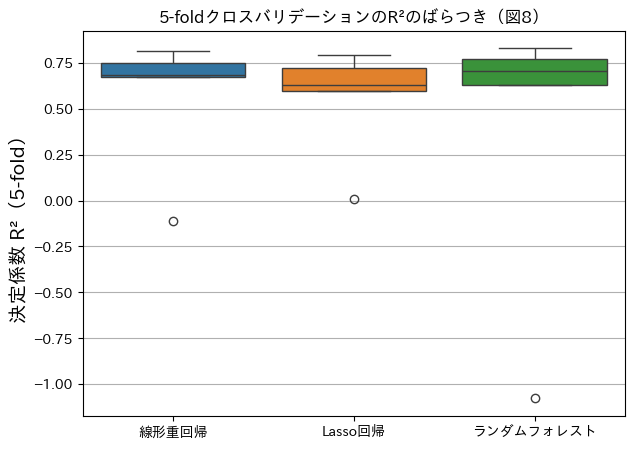

In [39]:
# 図8：5-fold クロスバリデーションのばらつきを箱ひげ図で可視化
fig, ax = plt.subplots(figsize=(7,5))

sns.boxplot(data=pd.DataFrame(cv_results), ax=ax)
ax.set_ylabel('決定係数 R²（5-fold）', fontsize=14)
ax.grid(axis='y')
plt.title('5-foldクロスバリデーションのR²のばらつき（図8）')
plt.show()

## 6. 【発展】未知の「地点」に対する汎化性能

ここまでのtrain/test分割やクロスバリデーションは、71件のレコードを**ランダムに**シャッフルして分割していました。しかし、前編（EDA編）で確認した通り、このデータは実際には**6地点×約12か月**という構造を持っています。ランダムな分割では、テストデータに含まれる地点の多くが、訓練データにも（違う月として）含まれてしまいます。

つまり、ここまでの評価は「**同じ地点の、違う月**」を当てる性能を測っているだけであり、「**まったく新しい地点**」に対してどれだけ予測できるかは、まだ確認していません。実務でこのモデルを使う場面（例：これまで測定していない新しい地点の腐食速度を予測したい）を考えると、後者の方がずっと重要な問いです。

`GroupKFold`を使うと、「同じグループ（ここでは地点）が訓練とテストの両方に混ざらないように」分割できます。試してみましょう。

In [40]:
from sklearn.model_selection import GroupKFold

groups = X.index.values  # 地点名（Place）をグループとして使う

gkf = GroupKFold(n_splits=6)  # 6地点なので6分割（1地点を残してテストに使う「leave-one-site-out」）

pipe_lr = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
site_scores = cross_val_score(pipe_lr, X, y, cv=gkf, groups=groups, scoring='r2')

for site, score in zip(pd.unique(groups), site_scores):
    print(f'テスト地点: {site:12s}  R2: {score:.3f}')
print()
print('平均R2:', round(site_scores.mean(), 3), ' 標準偏差:', round(site_scores.std(), 3))

テスト地点: Naha          R2: -3.934
テスト地点: Miyakojima    R2: -2.272
テスト地点: Fukuoka       R2: 0.508
テスト地点: Shizuoka      R2: -1.662
テスト地点: Tsukuba       R2: -1.664
テスト地点: Choshi        R2: 0.607

平均R2: -1.403  標準偏差: 1.58


### 【重要な結論】ランダム分割とグループ分割で、評価はまったく違うものになります

この結果は、ここまでの結果（図7・図8）とは対照的なはずです。多くの地点で決定係数が**マイナス**になっている（＝平均値をそのまま予測するより悪い）ことが分かります。これは、**このモデルが「まったく新しい地点」に対してはほとんど汎化できていない**ことを意味します。

なぜこうなるのでしょうか。考えられる理由は次の通りです。

* 6地点しかないため、訓練に使える地点は最大5つ。地点固有の要因（海からの距離、局所的な塩害の強さなど、気象データだけでは表現しきれない要因）を、モデルが気象変数だけから学習しきれない。
* ある地点の気候パターンが、残りの地点と大きく異なる場合、その地点は「外挿」（訓練データの範囲外への予測）になりやすい。

**この章の教訓：** 「テストデータでのR²が高い」ことは、「モデルが本当に汎化している」ことを必ずしも意味しません。**テストデータの取り方（何を"未知"とみなすか）が、評価の意味を決めます。** 実務でモデルを使う前には、「このモデルに何を予測させたいのか」「テストデータはその状況を正しく再現できているか」を必ず確認してください。

---

# 7. まとめと演習問題

## まとめ

本ノートブックでは、次のことを学びました。

* 住宅価格編と同じコード構成（線形重回帰・Lasso回帰・ランダムフォレストの構築と比較）が、題材（気象データ→腐食量）が変わっても通用すること
* 標準化は訓練データで`fit`し、テストデータには`transform`のみを適用する（データリーケージを避ける）正しい手順
* サンプル数が少ない（71件）場合、1回だけのtrain/test分割による評価は乱数シードによって大きく変動し、信頼できないこと（実際に複数のシードで確認しました）
* `cross_val_score`と`KFold`によるk-foldクロスバリデーションで、より安定した性能評価を得る方法
* `GroupKFold`を使い、「同じ地点は訓練・テストのどちらか一方にしかない」という条件で評価すると、ランダム分割とはまったく違う（はるかに悪い）結果になること、およびその解釈

## 本ノートブックでは扱っていないこと（今後の課題）

1. **ハイパーパラメータの調整（グリッドサーチ・ランダムサーチ）は行っていません。**
2. **`Month`の季節性を明示的な特徴量として使っていません。**
3. **地点固有の情報（海からの距離、地形など）を説明変数に追加していません。** これが「6. 未知の地点への汎化」がうまくいかない一因である可能性があります。

## 演習問題

1. 図8の箱ひげ図で、3モデルのうちどれが最も安定している（ばらつきが小さい）か確認してみましょう。
2. `GroupKFold`の結果で、どの地点をテストにしたときに決定係数が最も悪化したか確認し、前編（EDA編）のヒートマップや箱ひげ図からその地点の気象条件にどんな特徴がありそうか考察してみましょう。
3. `RandomForestRegressor`の`n_estimators`を10・50・100・300と変えて、5-foldクロスバリデーションの平均R²と標準偏差がどう変化するか確認してみましょう。

## Closing：次回予告

さらに機械学習モデルの精度をあげるために、**ハイパーパラメータ調整**（グリッドサーチ・ランダムサーチ・ベイズ最適化）を行います。k-foldクロスバリデーションは本編で実際に扱いましたが、ハイパーパラメータ調整と組み合わせる方法（`GridSearchCV`・`RandomizedSearchCV`）は次のノートブックで扱います。